# Multi-turn Conversation Activation Analysis
Analysis dimensions: conversational behavior / activation-correctness relationship / activation dynamics / layer contribution comparison

## 0. Dependencies and Imports

In [1]:
import json
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from collections import Counter, defaultdict
from pathlib import Path
from sklearn.metrics import roc_auc_score

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')
print('✅ Dependencies imported successfully')

✅ Dependencies imported successfully


## 1. Data Loading

Three loading modes are supported:
- **A**: Specify a folder and automatically load all `.json` files
- **B**: Specify a file list
- **C**: Paste a JSON list directly (for small-scale debugging)

In [3]:
# ============================================================
# Modify settings here to switch the loading mode
# ============================================================

LOAD_MODE = 'files'   # 'folder' | 'files' | 'inline'

DATA_FOLDER = './logs'          # Used when LOAD_MODE='folder'
DATA_FILES  = ['logs/code/sharded-at0-ut0/sharded-at0-ut0_code_Qwen_Qwen2.5-14B-Instruct.jsonl']
# DATA_FILES  = ['logs/math/sharded-at0-ut0/(specific system prompt+no suffix)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct.jsonl']   # Used when LOAD_MODE='files'

# When LOAD_MODE='inline', paste your JSON list into RAW_DATA
RAW_DATA = [
    # Paste your JSON objects here
]

# ============================================================
def load_records():
    records = []
    if LOAD_MODE == 'folder':
        paths = glob.glob(os.path.join(DATA_FOLDER, '*.json'))
        for p in paths:
            with open(p, 'r', encoding='utf-8') as f:
                obj = json.load(f)
                # Support either a single dict or a list
                records.extend(obj if isinstance(obj, list) else [obj])
    elif LOAD_MODE == 'files':
        for p in DATA_FILES:
            with open(p, 'r', encoding='utf-8') as f:
                for line in f:
                    line = line.strip()
                    if line:
                        records.append(json.loads(line))
    elif LOAD_MODE == 'inline':
        records = RAW_DATA
    else:
        raise ValueError(f'Unknown LOAD_MODE: {LOAD_MODE}')
    return records

records = load_records()
print(f'✅ Loaded {len(records)} conversation records in total')

✅ Loaded 81 conversation records in total


## 2. Data Parsing -> Structured DataFrame

In [4]:
def parse_record(rec):
    """Extract all fields required for analysis from a single record."""
    trace = rec.get('trace', [])
    ar    = rec.get('activation_result', {})

    # ---------- Conversational behavior statistics ----------
    response_types = []
    answer_attempts = []
    num_turns = 0          # Number of user turns
    num_assistant = 0
    for entry in trace:
        role = entry.get('role', '')
        if role == 'user':
            num_turns += 1
        elif role == 'assistant':
            num_assistant += 1
        elif role == 'log':
            content = entry.get('content', {})
            if isinstance(content, dict):
                if content.get('type') == 'system-verification':
                    rt = content.get('response', {}).get('response_type', 'unknown')
                    response_types.append(rt)
                elif content.get('type') == 'answer-evaluation':
                    answer_attempts.append({
                        'exact_answer': content.get('exact_answer'),
                        'is_correct':   content.get('is_correct'),
                        'score':        content.get('score', 0.0),
                    })

    rt_counter = Counter(response_types)

    # ---------- Activation values ----------
    delta_scores      = ar.get('delta_scores', [])        # shape: [num_shards]
    cumulative_scores = ar.get('cumulative_scores', [])   # shape: [num_shards+1]
    delta_per_layer   = ar.get('delta_per_layer', [])     # shape: [num_shards, num_layers]
    cumulative_per_layer = ar.get('cumulative_per_layer', [])  # shape: [num_shards+1, num_layers]

    num_layers = len(delta_per_layer[0]) if delta_per_layer else 0
    num_shards = len(delta_scores)

    # First answer attempt vs. final attempt
    first_attempt = answer_attempts[0]  if answer_attempts else {}
    last_attempt  = answer_attempts[-1] if answer_attempts else {}

    # Canonical correctness rule: score == 0 -> incorrect, otherwise correct.
    raw_score = rec.get('score', 0.0)
    try:
        final_score = float(raw_score)
    except (TypeError, ValueError):
        final_score = 0.0
    is_correct_by_score = (final_score != 0.0)

    return {
        # Metadata
        'conv_id':       rec.get('conv_id'),
        'task':          rec.get('task'),
        'task_id':       rec.get('task_id'),
        'conv_type':     rec.get('conv_type'),
        'assistant_model': rec.get('assistant_model'),

        # Outcomes
        'is_correct_raw': rec.get('is_correct'),
        'is_correct':    is_correct_by_score,
        'final_score':   final_score,
        'first_correct': first_attempt.get('is_correct'),
        'num_answer_attempts': len(answer_attempts),

        # Conversational behavior
        'num_user_turns':     num_turns,
        'num_assistant_turns': num_assistant,
        'num_clarifications': rt_counter.get('clarification', 0),
        'num_discussions':    rt_counter.get('discussion', 0),
        'num_answer_resp':    rt_counter.get('answer_attempt', 0),
        'response_types_seq': response_types,   # Full sequence for order analysis

        # Activation values (global)
        'delta_scores':           delta_scores,
        'cumulative_scores':      cumulative_scores,
        'delta_per_layer':        delta_per_layer,
        'cumulative_per_layer':   cumulative_per_layer,
        'num_shards':             num_shards,
        'num_layers':             num_layers

        # Derived activation features
        ,'mean_delta':      np.mean(delta_scores) if delta_scores else np.nan
        ,'max_delta':       np.max(delta_scores)  if delta_scores else np.nan
        ,'final_cumulative': cumulative_scores[-1] if cumulative_scores else np.nan
        ,'peak_delta_shard': int(np.argmax(delta_scores)) if delta_scores else np.nan
    }

parsed = [parse_record(r) for r in records]
df = pd.DataFrame(parsed)
print(f'✅ Parsing completed: {len(df)} rows, {len(df.columns)} columns')
df[['conv_id','task','is_correct','num_user_turns','num_clarifications',
    'mean_delta','final_cumulative']].head(10)

✅ Parsing completed: 81 rows, 26 columns


,conv_id,task,is_correct,num_user_turns,num_clarifications,mean_delta,final_cumulative
0,69d782b6459230af8f3a67f4,code,True,4,0,0.069903,0.195026
1,69d7831e459230af8f3a67f5,code,False,7,0,0.054966,0.182602
2,69d783d3459230af8f3a67f6,code,False,5,0,0.068889,0.220698
3,69d783ef459230af8f3a67f7,code,True,3,0,0.105925,0.201627
4,69d7845b459230af8f3a67f8,code,False,7,0,0.045193,0.172359
5,69d78485459230af8f3a67f9,code,True,6,0,0.073623,0.188931
6,69d7849f459230af8f3a67fa,code,True,4,0,0.073324,0.205695
7,69d785a6459230af8f3a67fb,code,False,8,0,0.050900,0.191257
8,69d785b6459230af8f3a67fc,code,True,3,0,0.112574,0.184587
9,69d785fe459230af8f3a67fd,code,False,6,0,0.062557,0.201124


In [5]:
# Quick statistics overview (original, unbalanced)
print('=== Basic Statistics (Original) ===')

s = df['is_correct']
correct_cnt = s.eq(True).sum()
incorrect_cnt = s.eq(False).sum()
missing_cnt = s.isna().sum()
valid_cnt = correct_cnt + incorrect_cnt

print(f'Total conversations            : {len(df)}')
print(f'Correct / Incorrect / Missing  : {correct_cnt} / {incorrect_cnt} / {missing_cnt}')
print(f'Accuracy (valid only)          : {correct_cnt / valid_cnt:.2%}' if valid_cnt else 'Accuracy (valid only)          : N/A')
print(f'Avg. user turns                : {df.num_user_turns.mean():.3f}')
print(f'Avg. assistant turns           : {df.num_assistant_turns.mean():.3f}')
print(f'Avg. user turns by correctness : {df.groupby("is_correct").num_user_turns.mean().to_dict()}')

=== Basic Statistics (Original) ===
Total conversations            : 81
Correct / Incorrect / Missing  : 47 / 34 / 0
Accuracy (valid only)          : 58.02%
Avg. user turns                : 4.556
Avg. assistant turns           : 4.556
Avg. user turns by correctness : {False: 6.470588235294118, True: 3.1702127659574466}



=== Normal Fit on num_user_turns ===
Correct   : n=47, mu=3.1702, sigma=1.8803
Incorrect : n=34, mu=6.4706, sigma=1.4192


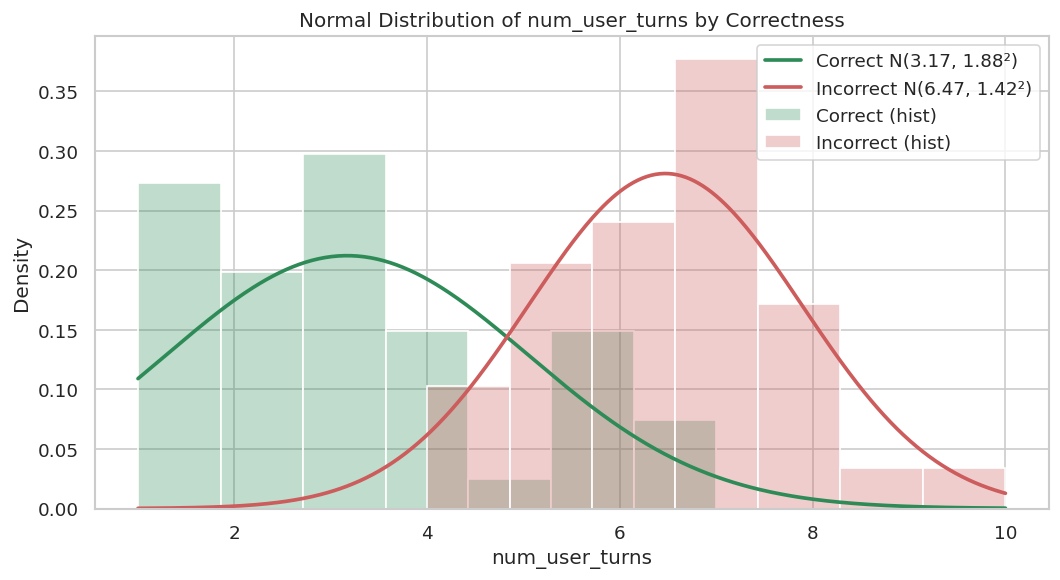

In [6]:
# ===== Normal distribution of num_user_turns for correct vs incorrect =====
correct_turns = df.loc[df['is_correct'] == True, 'num_user_turns'].dropna().astype(float)
incorrect_turns = df.loc[df['is_correct'] == False, 'num_user_turns'].dropna().astype(float)

def fit_normal(x: pd.Series):
    if len(x) == 0:
        return np.nan, np.nan
    mu = float(np.mean(x))
    sigma = float(np.std(x, ddof=1)) if len(x) > 1 else 0.0
    return mu, sigma

mu_c, sigma_c = fit_normal(correct_turns)
mu_i, sigma_i = fit_normal(incorrect_turns)

print('\n=== Normal Fit on num_user_turns ===')
print(f'Correct   : n={len(correct_turns)}, mu={mu_c:.4f}, sigma={sigma_c:.4f}')
print(f'Incorrect : n={len(incorrect_turns)}, mu={mu_i:.4f}, sigma={sigma_i:.4f}')

# Plot histogram + fitted normal curves
plt.figure(figsize=(9, 5))

if len(correct_turns) > 0:
    sns.histplot(correct_turns, stat='density', bins='auto', alpha=0.30, color='#2E8B57', label='Correct (hist)')
if len(incorrect_turns) > 0:
    sns.histplot(incorrect_turns, stat='density', bins='auto', alpha=0.30, color='#CD5C5C', label='Incorrect (hist)')

# Build x-axis range from available data
all_vals = pd.concat([correct_turns, incorrect_turns], ignore_index=True)
if len(all_vals) > 0:
    x_min, x_max = float(all_vals.min()), float(all_vals.max())
    if x_min == x_max:
        x_min -= 1.0
        x_max += 1.0
    x = np.linspace(x_min, x_max, 400)

    def normal_pdf(x, mu, sigma):
        if not np.isfinite(mu) or not np.isfinite(sigma):
            return np.full_like(x, np.nan, dtype=float)
        if sigma <= 1e-12:
            return np.zeros_like(x, dtype=float)
        return (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

    y_c = normal_pdf(x, mu_c, sigma_c)
    y_i = normal_pdf(x, mu_i, sigma_i)

    if np.isfinite(y_c).any():
        plt.plot(x, y_c, color='#2E8B57', linewidth=2.2, label=f'Correct N({mu_c:.2f}, {sigma_c:.2f}²)')
    if np.isfinite(y_i).any():
        plt.plot(x, y_i, color='#CD5C5C', linewidth=2.2, label=f'Incorrect N({mu_i:.2f}, {sigma_i:.2f}²)')

plt.title('Normal Distribution of num_user_turns by Correctness')
plt.xlabel('num_user_turns')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

=== Range-Filtered Normal Fit on num_user_turns ===
Filter range used: [1.00, 8.00]
Correct   : 47/47 kept, mu=3.1702, sigma=1.8803
Incorrect : 32/34 kept, mu=6.2812, sigma=1.2243


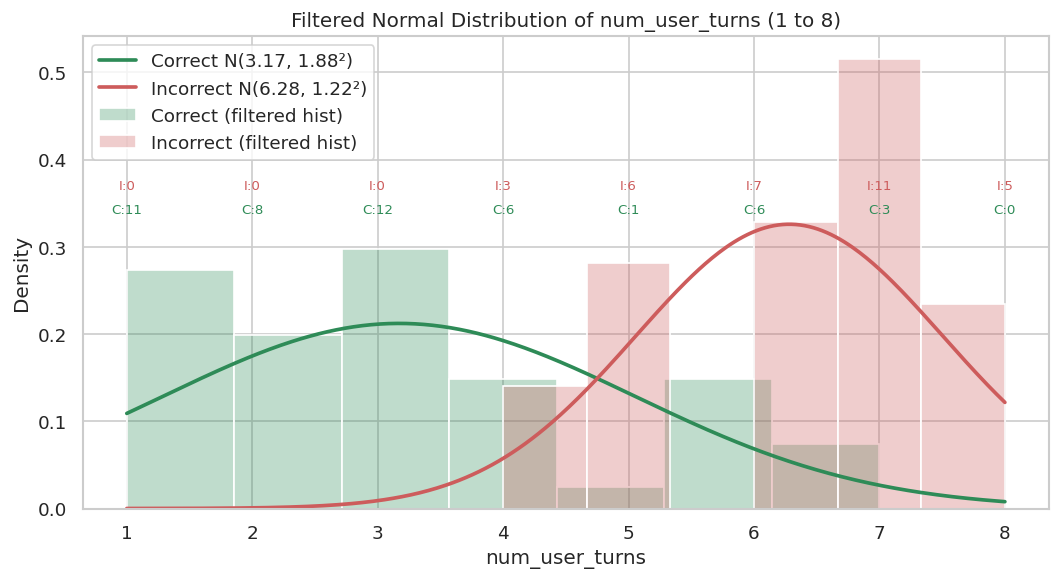

In [7]:
# ===== Range-filtered normal fit and plot (recommended: from start to 8) =====
print('=== Range-Filtered Normal Fit on num_user_turns ===')

all_turns = df['num_user_turns'].dropna().astype(float)

if len(all_turns) == 0:
    print('No num_user_turns data available.')
else:
    # Suggested by data shape + your idea: [min_turn, 8] with safety clamp to observed max
    fit_lo = float(all_turns.min())
    fit_hi = float(min(8.0, all_turns.max()))

    if fit_hi <= fit_lo:
        fit_hi = float(all_turns.max())

    print(f'Filter range used: [{fit_lo:.2f}, {fit_hi:.2f}]')

    correct_all = df.loc[df['is_correct'] == True, 'num_user_turns'].dropna().astype(float)
    incorrect_all = df.loc[df['is_correct'] == False, 'num_user_turns'].dropna().astype(float)

    correct_f = correct_all[correct_all.between(fit_lo, fit_hi, inclusive='both')]
    incorrect_f = incorrect_all[incorrect_all.between(fit_lo, fit_hi, inclusive='both')]

    def fit_normal_local(x: pd.Series):
        if len(x) == 0:
            return np.nan, np.nan
        mu = float(np.mean(x))
        sigma = float(np.std(x, ddof=1)) if len(x) > 1 else 0.0
        return mu, sigma

    mu_cf, sigma_cf = fit_normal_local(correct_f)
    mu_if, sigma_if = fit_normal_local(incorrect_f)

    print(f'Correct   : {len(correct_f)}/{len(correct_all)} kept, mu={mu_cf:.4f}, sigma={sigma_cf:.4f}')
    print(f'Incorrect : {len(incorrect_f)}/{len(incorrect_all)} kept, mu={mu_if:.4f}, sigma={sigma_if:.4f}')

    def normal_pdf_local(x, mu, sigma):
        if not np.isfinite(mu) or not np.isfinite(sigma):
            return np.full_like(x, np.nan, dtype=float)
        if sigma <= 1e-12:
            return np.zeros_like(x, dtype=float)
        return (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

    plt.figure(figsize=(9, 5))

    if len(correct_f) > 0:
        sns.histplot(correct_f, stat='density', bins='auto', alpha=0.30, color='#2E8B57', label='Correct (filtered hist)')
    if len(incorrect_f) > 0:
        sns.histplot(incorrect_f, stat='density', bins='auto', alpha=0.30, color='#CD5C5C', label='Incorrect (filtered hist)')

    x = np.linspace(fit_lo, fit_hi, 400)
    y_cf = normal_pdf_local(x, mu_cf, sigma_cf)
    y_if = normal_pdf_local(x, mu_if, sigma_if)

    if np.isfinite(y_cf).any():
        plt.plot(x, y_cf, color='#2E8B57', linewidth=2.2, label=f'Correct N({mu_cf:.2f}, {sigma_cf:.2f}²)')
    if np.isfinite(y_if).any():
        plt.plot(x, y_if, color='#CD5C5C', linewidth=2.2, label=f'Incorrect N({mu_if:.2f}, {sigma_if:.2f}²)')

    # Annotate per-turn sample counts for this filtered range
    integer_turns = np.arange(int(np.floor(fit_lo)), int(np.ceil(fit_hi)) + 1)
    c_counts = correct_f.round().astype(int).value_counts().to_dict()
    i_counts = incorrect_f.round().astype(int).value_counts().to_dict()

    y_top = 0.0
    if np.isfinite(y_cf).any():
        y_top = max(y_top, float(np.nanmax(y_cf)))
    if np.isfinite(y_if).any():
        y_top = max(y_top, float(np.nanmax(y_if)))
    y_base = y_top * 1.03 if y_top > 0 else 0.02

    for t in integer_turns:
        c_n = int(c_counts.get(t, 0))
        i_n = int(i_counts.get(t, 0))
        if c_n == 0 and i_n == 0:
            continue
        # Slight vertical staggering to reduce overlap
        plt.text(t, y_base, f'C:{c_n}', color='#2E8B57', ha='center', va='bottom', fontsize=8)
        plt.text(t, y_base * 1.08, f'I:{i_n}', color='#CD5C5C', ha='center', va='bottom', fontsize=8)

    plt.title(f'Filtered Normal Distribution of num_user_turns ({fit_lo:.0f} to {fit_hi:.0f})')
    plt.xlabel('num_user_turns')
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [69]:
# Rebuild df for downstream analysis
print('=== Rebuild df for downstream analysis ===')

# Start from full parsed data if available (avoid carrying previous temporary filters)
if 'parsed' in globals():
    df_base = pd.DataFrame(parsed).copy()
else:
    df_base = df.copy()

# If range variables exist, keep consistency with the filtered distribution fitting
use_range_filter = ('fit_lo' in globals()) and ('fit_hi' in globals())

if use_range_filter:
    lo, hi = float(fit_lo), float(fit_hi)
    mask = df_base['is_correct'].isin([True, False]) & df_base['num_user_turns'].between(lo, hi, inclusive='both')
    print(f'Using range filter: [{lo:.2f}, {hi:.2f}]')
else:
    mask = df_base['is_correct'].isin([True, False])
    print('No range filter found, using all valid correct/incorrect rows.')

df_correct = df_base[mask & df_base['is_correct'].eq(True)].copy()
df_incorrect = df_base[mask & df_base['is_correct'].eq(False)].copy()

df = (
    pd.concat([df_correct, df_incorrect], ignore_index=True)
    .sample(frac=1.0, random_state=42)
    .reset_index(drop=True)
)

print(f'Rebuilt df rows         : {len(df)}')
print(f'Correct / Incorrect     : {df["is_correct"].eq(True).sum()} / {df["is_correct"].eq(False).sum()}')
print(f'num_user_turns min/max  : {df["num_user_turns"].min()} / {df["num_user_turns"].max()}')

df[['conv_id', 'is_correct', 'num_user_turns']].head(10)

=== Rebuild df for downstream analysis ===
Using range filter: [1.00, 8.00]
Rebuilt df rows         : 198
Correct / Incorrect     : 106 / 92
num_user_turns min/max  : 1 / 7


,conv_id,is_correct,num_user_turns
0,69d6670fe16ebbccdc18410b,True,4
1,69d65ddfe16ebbccdc1840a9,False,4
2,69d65f84e16ebbccdc1840bb,True,1
3,69d6648ce16ebbccdc1840ee,False,5
4,69d667bee16ebbccdc184111,False,4
5,69d66098e16ebbccdc1840c5,False,4
6,69d66453e16ebbccdc1840ec,False,4
7,69d661b2e16ebbccdc1840d1,True,4
8,69d65fd3e16ebbccdc1840be,True,4
9,69d66916e16ebbccdc184120,False,5


---
## 3. Conversational Behavior Analysis
### 3.1 Response Type Distribution

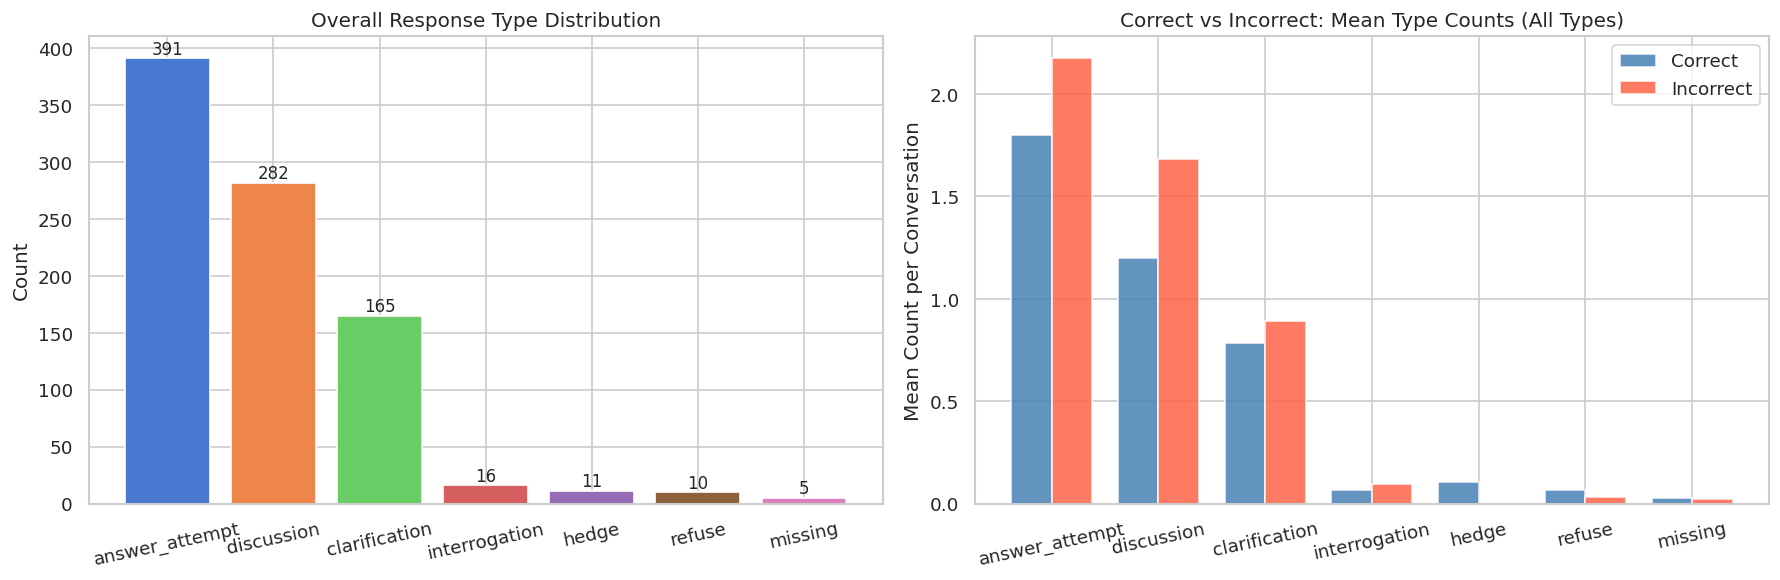

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ---- Left: overall response type distribution ----
all_types = [t for seq in df.response_types_seq for t in seq]
type_counts = Counter(all_types)
labels, values = zip(*sorted(type_counts.items(), key=lambda x: -x[1]))

bars = axes[0].bar(labels, values, color=sns.color_palette('muted', len(labels)))
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', va='bottom', fontsize=10)
axes[0].set_title('Overall Response Type Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=12)

# ---- Right: behavior comparison between correct and incorrect conversations ----
# Use the same full type list as the left chart, then compute per-conversation mean counts.
type_order = list(labels)

type_count_rows = []
for seq in df['response_types_seq']:
    c = Counter(seq)
    type_count_rows.append({t: c.get(t, 0) for t in type_order})

type_count_df = pd.DataFrame(type_count_rows)
type_count_df['is_correct'] = df['is_correct'].values

group_means = type_count_df.groupby('is_correct')[type_order].mean()

correct_means = group_means.loc[True] if True in group_means.index else pd.Series(0.0, index=type_order)
incorrect_means = group_means.loc[False] if False in group_means.index else pd.Series(0.0, index=type_order)

x = np.arange(len(type_order))
w = 0.38
axes[1].bar(x - w/2, correct_means.values,   w, label='Correct', color='steelblue', alpha=0.85)
axes[1].bar(x + w/2, incorrect_means.values, w, label='Incorrect', color='tomato',    alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(type_order, rotation=12)
axes[1].set_title('Correct vs Incorrect: Mean Type Counts (All Types)')
axes[1].set_ylabel('Mean Count per Conversation')
axes[1].legend()

plt.tight_layout()
# plt.savefig('analyse/fig1_behavior_distribution.png', bbox_inches='tight')
plt.show()